In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

import scienceplots
plt.style.use(['science', 'no-latex'])

### Conversions

In [2]:
MSOL_PER_IU = 1E10
KPC_PER_IU = 1.0
KMS_PER_IU = 207.38652969844208
MYR_PER_IU = 4.714829951118732 

### Data

In [3]:
t_r = MYR_PER_IU / 100 * np.array([1457.504,
                  1901.125,
                  2844.529,
                  4126.62])
t_r_err = MYR_PER_IU / 100 *  np.array([17.774, 23.184, 29.026, 176.353])
r = KPC_PER_IU * np.array([4, 5, 6, 7])

t_M = np.array([1757.383,
                   904.199,
                   741.906,
                   625.984])
t_M_err = np.array([74.189, 69.554, 23.185, 23.185])
M = np.array([0.01, 0.033, 0.066, 0.1])

### t_df vs radius

In [28]:
def t_r_fit (x, A, B):
    y = A*x**B
    return y

In [37]:
r_par, r_cov = curve_fit(t_r_fit, r, t_r)

r_A, r_B = r_par
print('Cov. matrix condition number = ', np.linalg.cond(r_cov), ', diag. elements = ', np.diag(r_cov))

chi2 = np.sum((t_r-t_r_fit(r,r_A,r_B))**2/t_r_err**2)
dof = len(r) - 2
chi2_r = chi2 / dof
print('reduced chi2 = ', chi2_r)

Cov. matrix condition number =  5800.510859560371 , diag. elements =  [1.70183218 0.04242564]
reduced chi2 =  71.69336533863105


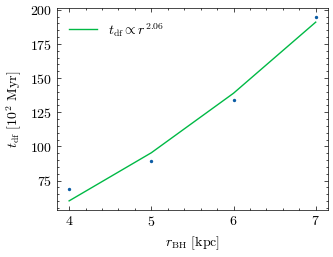

In [16]:
plt.scatter(r, t_r, s = 2)
plt.plot(r, t_r_fit(r, r_A, r_B), label = r'$t_\mathrm{{df}} \propto r^{{{:.{p}f}}}$'.format(r_B, p=2), c = 'C1')
plt.legend()
plt.xlabel(r'$r_\mathrm{BH}$ [kpc]')
plt.ylabel(r'$t_\mathrm{df}$ [10$^2$ Myr]')
plt.show()

### t_df vs mass

In [7]:
def t_M_fit (x, A, B):
    y = A + B*x**(-1)
    return y

In [38]:
M_par, M_cov = curve_fit(t_M_fit, M, t_M)

M_A, M_B = M_par
print('Cov. matrix condition number = ', np.linalg.cond(M_cov), ', diag. elements = ', np.diag(M_cov))

chi2 = np.sum((t_M-t_M_fit(M,M_A,M_B))**2/t_M_err**2)
dof = len(M) - 2
chi2_r = chi2 / dof
print('reduced chi2 = ', chi2_r)

Cov. matrix condition number =  6077.347512591758 , diag. elements =  [3.75259147e+02 1.33451071e-01]
reduced chi2 =  1.2854841814767304


In [39]:
M_par_1, M_cov_1 = curve_fit(t_r_fit, M, t_M, sigma = t_M_err)

M_A_1, M_B_1 = M_par_1
print('Cov. matrix condition number = ', np.linalg.cond(M_cov_1), ', diag. elements = ', np.diag(M_cov_1))

chi2 = np.sum((t_M-t_r_fit(M,M_A_1,M_B_1))**2/t_M_err**2)
dof = len(M) - 2
chi2_r = chi2 / dof
print('reduced chi2 = ', chi2_r)

Cov. matrix condition number =  6757833.962631038 , diag. elements =  [3.68526741e+02 7.47560281e-04]
reduced chi2 =  1.3745196630344654


# I valori del fit sono in IU!!

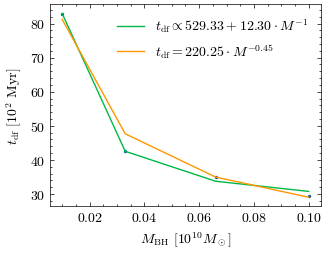

In [15]:
plt.scatter(M, MYR_PER_IU/100* t_M, s = 2)
plt.plot(M, MYR_PER_IU/100 * t_M_fit(M, M_A, M_B), label = r'$t_\mathrm{{df}} \propto {:.{p}f} + {:.{p}f} \cdot M^{{-1}}$'.format( M_A, M_B,  p=2), c = 'C1')
plt.plot(M, MYR_PER_IU/100 * t_r_fit(M, M_A_1, M_B_1), label = r'$t_\mathrm{{df}} = {:.{p}f} \cdot M^{{{:.{p}f}}}$'.format(M_A_1, M_B_1, p=2), c='C2')
#plt.plot(M, t_M_fit(M, 60, 15, -1))
plt.xlabel(r'$M_\mathrm{BH}$ [10$^{10} M_\odot$]')
plt.ylabel(r'$t_\mathrm{df}$ [10$^2$ Myr]')
plt.legend()
plt.show()